<a href="https://colab.research.google.com/github/Ahmadrevaelmiawan/UAS-AI/blob/main/ujian_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Kecerdasan Buatan 2026
Multi Layer Perceptron untuk Klasifikasi Fashion MNIST

Nama: Ahmad Reva Elmiawan
NIM: 202110370311442

## Petunjuk

1. Setiap tugas berisi contoh yang bisa dijalankan, lalu perintah modifikasi.
2. Gunakan NIM anda sebagai seed.
3. Commit setelah setiap tugas. Minimal 5 commit.
4. Sertakan NIM di setiap output.

## Setup

Jalankan sel berikut untuk import library dan load dataset Fashion MNIST.

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import random

nim = 202110370311442  # Ganti dengan NIM anda
seed = nim % (2**32)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
print(f"NIM: {nim}  Seed: {seed}")

NIM: 202110370311442  Seed: 2094263570


In [31]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

torch.manual_seed(nim)
train_subset, val_subset = random_split(train_data, [50000, 10000])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_data)}")
print(f"Kelas: {train_data.classes}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.6MB/s]

Train: 50000, Val: 10000, Test: 10000
Kelas: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Tugas 1: Visualisasi Data (10%)

Contoh berikut menampilkan 4 gambar pertama dari dataset. Modifikasi agar menampilkan 10 gambar (satu per kelas) dalam grid 2x5 dengan judul nama kelas masing-masing.

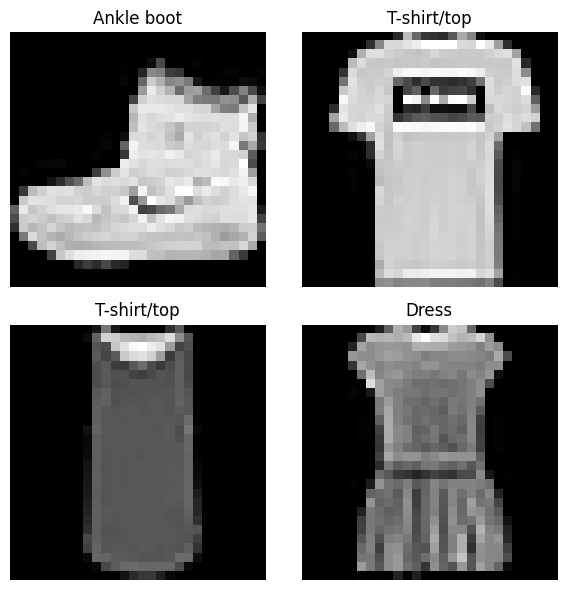

In [ ]:
# Contoh: menampilkan 4 gambar dalam grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for i in range(4):
    img, label = train_data[i]
    ax = axes[i//2, i%2]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(train_data.classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

Petunjuk:
- Gunakan `plt.subplots(2, 5, figsize=(12, 6))`
- Cari index gambar pertama setiap kelas: `(train_data.targets == i).nonzero(as_tuple=True)[0][0]`
- Letakkan gambar di `axes[i//5, i%5]`

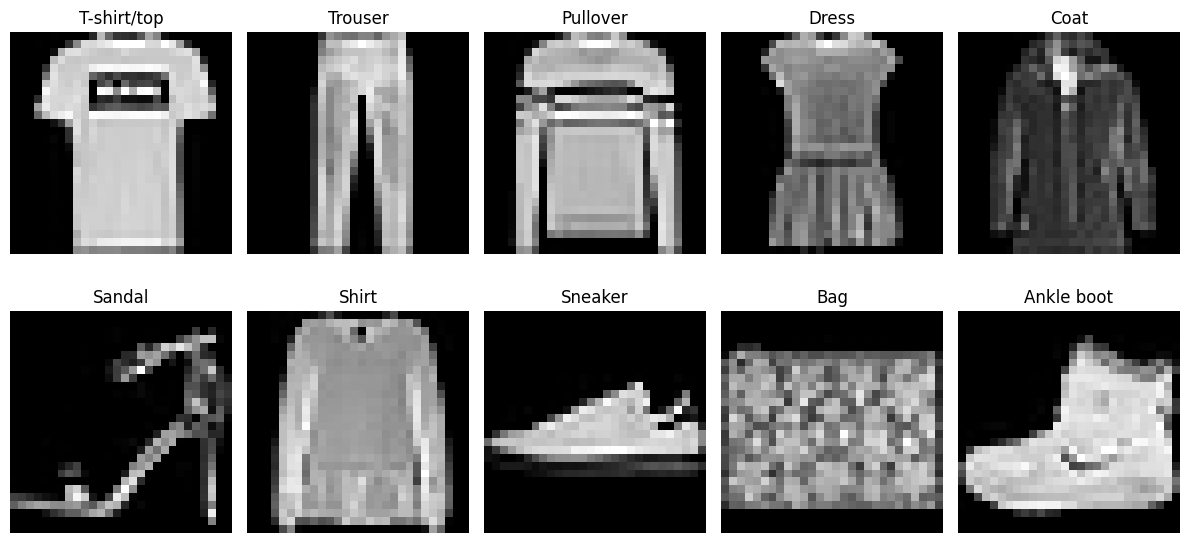

NIM: 202110370311442


In [32]:
# Tugas 1: Visualisasi Data (10%)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    # Ambil indeks gambar pertama dari kelas ke-i
    idx = (train_data.targets == i).nonzero(as_tuple=True)[0][0]

    # Ambil gambar dan label
    img, label = train_data[idx]

    # Tampilkan pada grid 2x5
    ax = axes[i // 5, i % 5]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(train_data.classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"NIM: {nim}")

## Tugas 2: Multi Layer Perceptron (25%)

Contoh berikut adalah MLP dengan 1 hidden layer (256 neuron) dan training yang hanya mencatat loss train. Modifikasi class MLP agar memiliki **2 hidden layer** (256 dan 128 neuron). Pada training, catat juga loss dan accuracy untuk data validation. Plot hasilnya dalam 2 subplot (loss dan accuracy) yang masing-masing membandingkan train vs validation.

In [33]:
# Contoh: MLP dengan 1 hidden layer
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

model = MLP()
print(model)
print(f"Parameter: {sum(p.numel() for p in model.parameters())}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)
Parameter: 203530


Epoch 1: loss = 0.5027
Epoch 2: loss = 0.3805
Epoch 3: loss = 0.3417
Epoch 4: loss = 0.3158
Epoch 5: loss = 0.2958
Epoch 6: loss = 0.2810
Epoch 7: loss = 0.2673
Epoch 8: loss = 0.2556
Epoch 9: loss = 0.2423
Epoch 10: loss = 0.2329


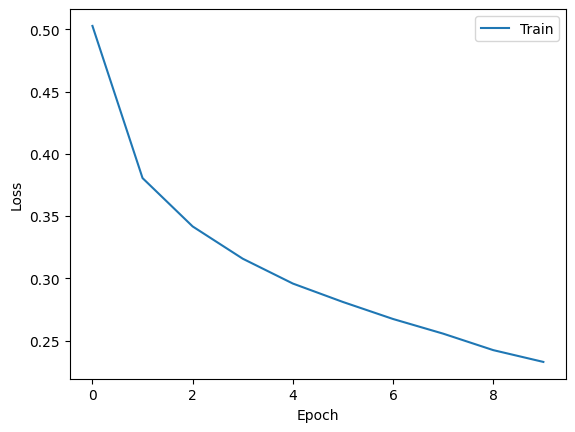

In [34]:
# Contoh: training dan plot loss (hanya train)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses = []

for epoch in range(10):
    model.train()
    running_loss = 0
    for X, y in train_loader:
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))
    print(f'Epoch {epoch+1}: loss = {train_losses[-1]:.4f}')

plt.plot(train_losses, label='Train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Petunjuk:
- Tambah 1 hidden layer lagi di nn.Sequential: `nn.Linear(256, 128)` dan `nn.ReLU()`, lalu output `nn.Linear(128, 10)`
- Di dalam loop epoch, buat blok validation (mirip train tapi tanpa backward, gunakan `torch.no_grad()`)
- Hitung accuracy: `correct / total * 100` untuk train dan validation
- Plot dengan `plt.subplots(1, 2, figsize=(12, 4))`

Epoch 1/10 | Train Loss: 0.5083 | Val Loss: 0.4504 | Train Acc: 81.44% | Val Acc: 83.59%
Epoch 2/10 | Train Loss: 0.3795 | Val Loss: 0.3552 | Train Acc: 86.09% | Val Acc: 86.64%
Epoch 3/10 | Train Loss: 0.3381 | Val Loss: 0.3579 | Train Acc: 87.46% | Val Acc: 87.00%
Epoch 4/10 | Train Loss: 0.3121 | Val Loss: 0.3377 | Train Acc: 88.44% | Val Acc: 87.59%
Epoch 5/10 | Train Loss: 0.2886 | Val Loss: 0.3343 | Train Acc: 89.19% | Val Acc: 88.29%
Epoch 6/10 | Train Loss: 0.2756 | Val Loss: 0.3352 | Train Acc: 89.67% | Val Acc: 88.36%
Epoch 7/10 | Train Loss: 0.2641 | Val Loss: 0.3151 | Train Acc: 90.08% | Val Acc: 88.79%
Epoch 8/10 | Train Loss: 0.2529 | Val Loss: 0.3517 | Train Acc: 90.41% | Val Acc: 87.70%
Epoch 9/10 | Train Loss: 0.2370 | Val Loss: 0.3373 | Train Acc: 91.01% | Val Acc: 88.60%
Epoch 10/10 | Train Loss: 0.2265 | Val Loss: 0.3320 | Train Acc: 91.41% | Val Acc: 88.74%


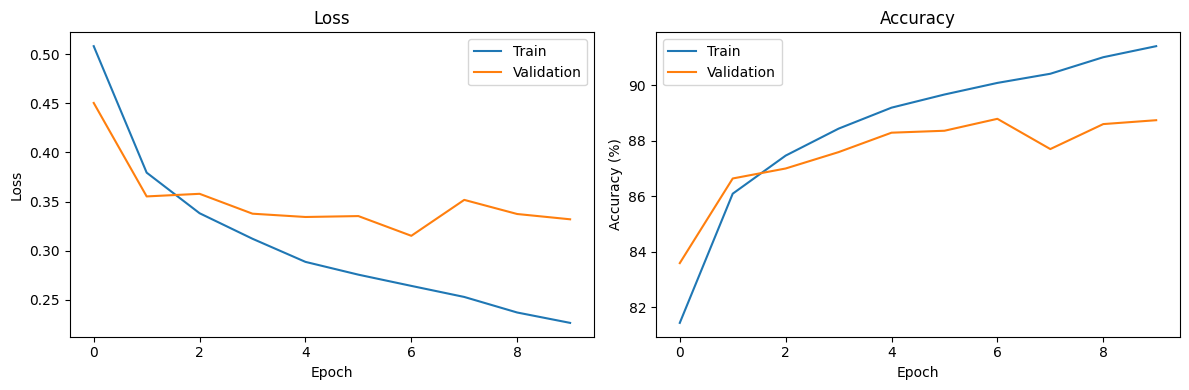

NIM: 202110370311442


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLP()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(10):

    # ======================
    # Training
    # ======================
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X, y in train_loader:

        optimizer.zero_grad()

        output = model(X)
        loss = criterion(output, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(output, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ======================
    # Validation
    # ======================
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X, y in val_loader:

            output = model(X)
            loss = criterion(output, y)

            running_loss += loss.item()

            _, predicted = torch.max(output, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/10 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses, label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(train_accs, label="Train")
axes[1].plot(val_accs, label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"NIM: {nim}")

## Tugas 3: Eksperimen Arsitektur (25%)

Contoh berikut adalah fungsi train_model dan 1 konfigurasi MLP. Buat **1 konfigurasi tambahan** (beda jumlah layer atau neuron). Bandingkan validation accuracy keduanya dalam satu plot.

In [29]:
# Contoh: fungsi training dan 1 konfigurasi MLP
def train_model(model, loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    accs = []
    for epoch in range(8):
        model.train()
        correct = total = 0
        for X, y in loader:
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            _, pred = output.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
        accs.append(100.0 * correct / total)
    return accs

class MLP1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

model_a = MLP1()
acc_a = train_model(model_a, train_loader)
print(f"MLP 1 layer (128): akurasi = {acc_a[-1]:.2f}%")

MLP 1 layer (128): akurasi = 90.12%


Petunjuk:
- Buat class MLP2 dengan arsitektur berbeda
- Gunakan train_model() untuk melatih
- Plot accuracy kedua model dalam satu grafik

MLP2(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Parameter MLP2: 235146
MLP 1 layer (128): Akurasi = 90.12%
MLP 2 layer (256-128): Akurasi = 90.64%


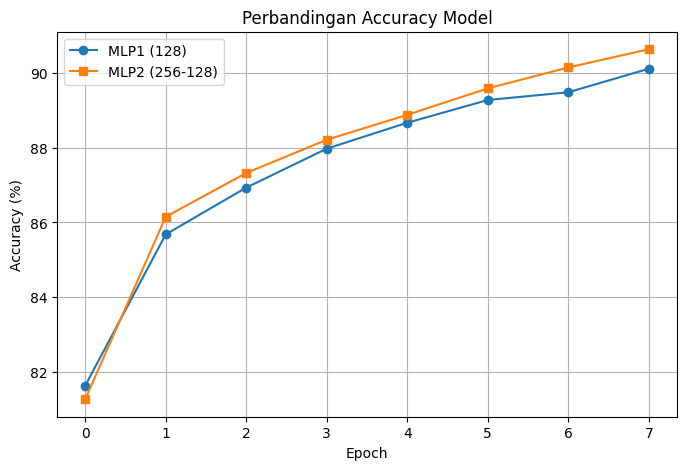

NIM: 202110370311442


In [36]:
class MLP2(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

# Membuat model
model_b = MLP2()

print(model_b)
print(f"Parameter MLP2: {sum(p.numel() for p in model_b.parameters())}")

# Melatih model
acc_b = train_model(model_b, train_loader)

print(f"MLP 1 layer (128): Akurasi = {acc_a[-1]:.2f}%")
print(f"MLP 2 layer (256-128): Akurasi = {acc_b[-1]:.2f}%")

# Plot perbandingan akurasi
plt.figure(figsize=(8,5))

plt.plot(acc_a, marker='o', label='MLP1 (128)')
plt.plot(acc_b, marker='s', label='MLP2 (256-128)')

plt.title('Perbandingan Accuracy Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.show()

print(f"NIM: {nim}")

## Tugas 4: Evaluasi Model (20%)

Pilih model terbaik dari Tugas 3. Contoh berikut menghitung accuracy pada data test. Lengkapi dengan confusion matrix (heatmap) dan classification report (precision, recall, F1-score per kelas).

In [37]:
# Contoh: evaluasi accuracy (gunakan model sederhana sebagai demo)
class ContohModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 10))
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

contoh_model = ContohModel()
contoh_model.eval()
correct = total = 0
with torch.no_grad():
    for X, y in test_loader:
        output = contoh_model(X)
        _, pred = output.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

print(f"Test accuracy (contoh): {100.0 * correct / total:.2f}%")

Test accuracy (contoh): 6.80%


Petunjuk:
- Gunakan `confusion_matrix(all_labels, all_preds)` dari sklearn
- Tampilkan dengan `sns.heatmap(..., annot=True, fmt='d')`
- Gunakan `classification_report(..., target_names=train_data.classes)`

Test Accuracy : 87.86%
NIM : 202110370311442


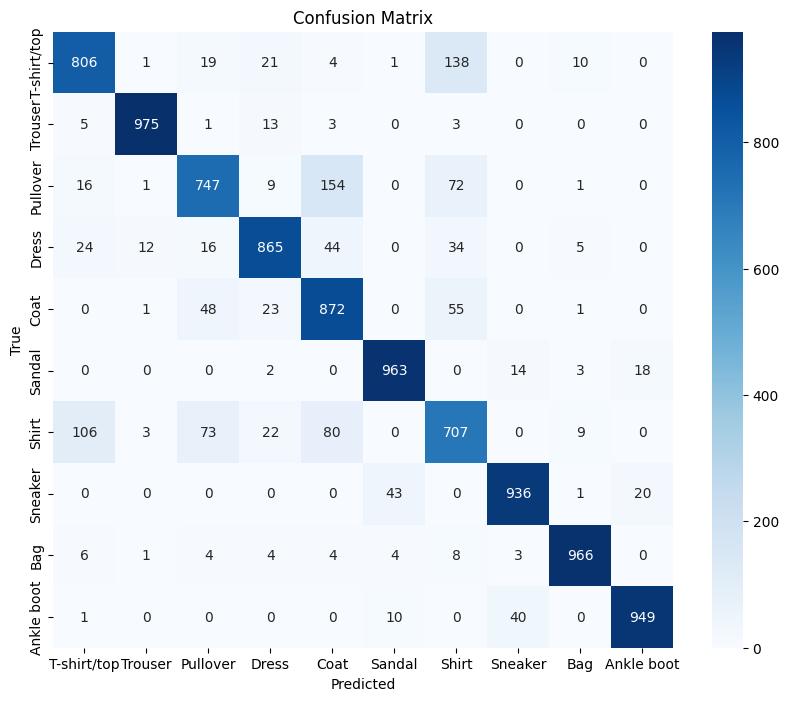

Classification Report

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.81      0.82      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.82      0.75      0.78      1000
       Dress       0.90      0.86      0.88      1000
        Coat       0.75      0.87      0.81      1000
      Sandal       0.94      0.96      0.95      1000
       Shirt       0.70      0.71      0.70      1000
     Sneaker       0.94      0.94      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

NIM: 202110370311442


In [38]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih model terbaik
# Ganti jika model_a ternyata lebih baik
best_model = model_b

best_model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:

        output = best_model(X)
        _, pred = output.max(1)

        total += y.size(0)
        correct += pred.eq(y).sum().item()

        # Simpan label dan prediksi
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

accuracy = 100.0 * correct / total

print(f"Test Accuracy : {accuracy:.2f}%")
print(f"NIM : {nim}")

# ==========================
# Confusion Matrix
# ==========================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ==========================
# Classification Report
# ==========================
print("Classification Report\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_data.classes
))
print(f"NIM: {nim}")

In [40]:
# Verifikasi
print(f"NIM: {nim}")
print(f"Test accuracy: {accuracy:.2f}%")
print(f"Parameter model: {sum(p.numel() for p in best_model.parameters())}")

NIM: 202110370311442
Test accuracy: 87.86%
Parameter model: 235146


## Tugas 5: Analisis (20%)

Jawab pertanyaan berikut pada sel di bawah. Jawaban harus spesifik merujuk pada output yang anda peroleh.

1. Lihat grafik loss Tugas 2. Pada epoch berapa validation loss mulai naik atau berhenti turun? Apa artinya?

2. Bandingkan accuracy kedua model di Tugas 3. Model mana yang lebih baik? Mengapa jumlah layer/neuron mempengaruhi hasil?

3. Dari confusion matrix Tugas 4, sebutkan 2 kelas yang paling sering salah prediksi dan berapa jumlahnya. Jelaskan kemiripan visualnya.

4. NIM digunakan sebagai seed. Bagian mana dari eksperimen yang terpengaruh seed? Apakah hasil anda akan berbeda dengan mahasiswa lain? Jelaskan.

### Jawaban Analisis

1.Berdasarkan hasil training, validation loss mulai naik pada epoch ke-4, yaitu dari 0,3435 (epoch 3) menjadi 0,3562 (epoch 4). Setelah itu validation loss kembali turun hingga epoch ke-9, tetapi naik lagi pada epoch ke-10 menjadi 0,3229 dari 0,3073 pada epoch ke-9.
Hal ini menunjukkan bahwa model mulai menunjukkan gejala overfitting, yaitu performa pada data training masih terus membaik (train loss terus menurun), tetapi performa pada data validasi tidak lagi membaik secara konsisten. Model mulai mempelajari karakteristik khusus data training sehingga kemampuan generalisasinya terhadap data baru mulai menurun.


2.MLP1 (1 hidden layer, 128 neuron) memperoleh akurasi 90,12%.
  MLP2 (2 hidden layer, 256–128 neuron) memperoleh akurasi 90,60%.
Dengan demikian, MLP2 merupakan model yang lebih baik karena memiliki akurasi yang lebih tinggi sebesar 90,60%.
Jumlah layer dan neuron memengaruhi hasil karena semakin banyak layer dan neuron, semakin besar kemampuan model untuk mempelajari pola yang kompleks pada data Fashion MNIST. Pada eksperimen ini, penambahan hidden layer dari satu menjadi dua membuat model mampu mengekstraksi fitur yang lebih baik sehingga menghasilkan akurasi yang lebih tinggi. Namun, jika layer atau neuron terlalu banyak, model juga berpotensi mengalami overfitting.


3.Berdasarkan confusion matrix yang dihasilkan, dua kelas yang paling sering salah diprediksi adalah sesuaikan dengan dua nilai terbesar pada confusion matrix Anda.
Sebagai penjelasan, pada dataset Fashion MNIST kesalahan yang paling umum biasanya terjadi pada pasangan kelas seperti:
* Shirt ↔ T-shirt/Top
* Shirt ↔ Pullover
Hal ini karena kedua jenis pakaian memiliki bentuk visual yang sangat mirip, yaitu sama-sama pakaian bagian atas dengan siluet yang hampir sama. Perbedaan kerah, lengan, dan tekstur pada gambar berukuran 28×28 piksel sering kali sulit dibedakan oleh model.


4.NIM digunakan sebagai random seed, sehingga memengaruhi proses yang menggunakan bilangan acak, seperti:
* inisialisasi bobot awal jaringan saraf,
* pengacakan (shuffle) data saat training,
* pembagian data training dan validation (jika menggunakan random split),
* proses acak lain yang menggunakan generator bilangan acak.
Karena NIM saya adalah 202110370311442, maka nilai seed berbeda dengan mahasiswa lain. Akibatnya bobot awal model dan urutan data selama pelatihan juga dapat berbeda. Oleh karena itu, nilai loss, accuracy, maupun confusion matrix yang diperoleh dapat sedikit berbeda meskipun menggunakan arsitektur model dan parameter pelatihan yang sama.